In [1]:
import pandas as pd

In [2]:
altin_data = pd.read_excel('/Users/yitik/Desktop/Dersler/For Python/InvestGuide/investment_ml/rawData/XAU_rawDataset.xlsx')
df = altin_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Tarih    1459 non-null   object
 1   Acilis   1459 non-null   object
 2   Kapanis  1459 non-null   object
dtypes: object(3)
memory usage: 34.3+ KB


In [5]:
df.head()

,Tarih,Acilis,Kapanis
0,7 Aralık 2020,"461,28","468,03"
1,8 Aralık 2020,"468,00","470,31"
2,9 Aralık 2020,"467,58","462,15"
3,10 Aralık 2020,"462,52","465,70"
4,11 Aralık 2020,"465,67","463,62"


In [71]:
df['Acilis'].apply(lambda x : x.replace('.', '')).tail() #Noktaları kaldırdım doğru oluyomu diye bakicam

1454    5764,63
1455    5781,25
1456    5745,21
1457    5740,34
1458    5753,02
Name: Acilis, dtype: object

In [9]:
df.Acilis = df['Acilis'].apply(lambda x : x.replace('.', ''))

In [77]:
df['Acilis'].apply(lambda x : x.replace(',', '.')) #Kontrol için

0        461.28
1        468.00
2        467.58
3        462.52
4        465.67
         ...   
1454    5764.63
1455    5781.25
1456    5745.21
1457    5740.34
1458    5753.02
Name: Acilis, Length: 1459, dtype: object

In [11]:
df.Acilis = df['Acilis'].apply(lambda x : float(x.replace(',', '.')))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tarih    1459 non-null   object 
 1   Acilis   1459 non-null   float64
 2   Kapanis  1459 non-null   object 
dtypes: float64(1), object(2)
memory usage: 34.3+ KB


In [13]:
def coverFloat(data):
    data = data.replace('.', '')
    return float(data.replace(',', '.'))

df.Kapanis = df['Kapanis'].apply(coverFloat)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tarih    1459 non-null   object 
 1   Acilis   1459 non-null   float64
 2   Kapanis  1459 non-null   float64
dtypes: float64(2), object(1)
memory usage: 34.3+ KB


In [17]:
aylar = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# Tarih sütunundaki ay isimlerini değiştirme
for tr, num in aylar.items():
    df['Tarih'] = df['Tarih'].str.replace(tr, num, regex=False)

# 2. Datetime formatına çevirme (Gün Ay Yıl formatında olduğu için dayfirst=True)
# Artık format "15 10 2021" gibi oldu, bunu datetime'a çeviriyoruz.
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tarih    1459 non-null   datetime64[ns]
 1   Acilis   1459 non-null   float64       
 2   Kapanis  1459 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 34.3 KB
None


In [117]:
df.head(15)

,Tarih,Acilis,Kapanis
0,2020-12-07,461.28,468.03
1,2020-12-08,468.00,470.31
2,2020-12-09,467.58,462.15
3,2020-12-10,462.52,465.70
4,2020-12-11,465.67,463.62
5,2020-12-12,465.63,463.62
6,2020-12-14,464.20,461.52
7,2020-12-15,461.70,467.22
8,2020-12-16,467.22,467.63
9,2020-12-17,467.82,466.69


In [21]:
def ml_icin_hazirla(df):
    # Tarihi parçalarına ayırıyoruz ki model (Random Forest vb.) anlayabilsin
    df['Yil'] = df['Tarih'].dt.year
    df['Ay'] = df['Tarih'].dt.month
    df['Gun'] = df['Tarih'].dt.day
    df['HaftaninGunu'] = df['Tarih'].dt.dayofweek # 0: Pzt, 6: Paz
    
    # İPUCU: Finans verisinde "Lag" (Gecikmeli) özellikler model başarısını çok artırır.
    # "Bugünün fiyatını tahmin etmek için dünün kapanış fiyatını kullan" mantığı.
    df['Dunku_Kapanis'] = df['Kapanis'].shift(1)
    
    # İlk satırda "dün" olmadığı için NaN oluşur, siliyoruz
    df = df.dropna(inplace = True)
    
    return df

In [23]:
ml_icin_hazirla(df)

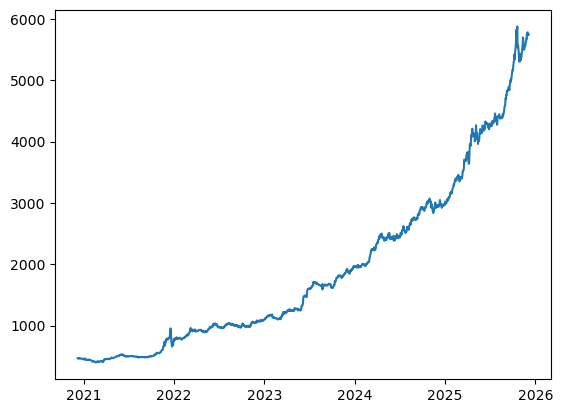

In [127]:
import matplotlib.pyplot as plt
plt.plot(df['Tarih'], df['Kapanis'])

In [27]:
df.set_index('Tarih').resample('M').mean()[['Acilis', 'Kapanis']]

/var/folders/22/j5k7n31s4p1fkq4x0frr3myc0000gn/T/ipykernel_5582/2926793234.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Tarih').resample('M').mean()[['Acilis', 'Kapanis']]


,Acilis,Kapanis
Tarih,,
2020-12-31,461.342500,460.424500
2021-01-31,444.649200,443.000000
2021-02-28,413.074167,411.807500
2021-03-31,424.401852,424.427778
2021-04-30,460.896667,461.453750
...,...,...
2025-08-31,4411.668571,4424.358095
2025-09-30,4840.295217,4869.129565
2025-10-31,5195.432174,5459.862174


In [25]:
X = df[['Yil', 'Ay', 'Gun', 'HaftaninGunu', 'Dunku_Kapanis']]
y = df.Kapanis

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = False)

In [31]:
print(f"Eğitim Verisi: {X_train.shape[0]} satır")
print(f"Test Verisi: {X_test.shape[0]} satır")

Eğitim Verisi: 1166 satır
Test Verisi: 292 satır


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    # --- Temel Model ---
    "Linear Regression": LinearRegression(),
    
    # --- Regularization (Ceza) Ekleyen Modeller ---
    # Overfitting'i engeller, değişkenler arası korelasyonu (dolar vs euro gibi) yönetir.
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    
    # --- Gürültüye Dayanıklı (Robust) Modeller ---
    # Altın fiyatlarındaki ani iğne atışlarını (outlier) görmezden gelerek trendi yakalar.
    "Huber Regressor": HuberRegressor(max_iter=2000), # Yakınsama için iterasyonu artırdık
    "Bayesian Ridge": BayesianRidge(),
    
    # --- Ağaç Tabanlı Modeller (Kıyaslama için) ---
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

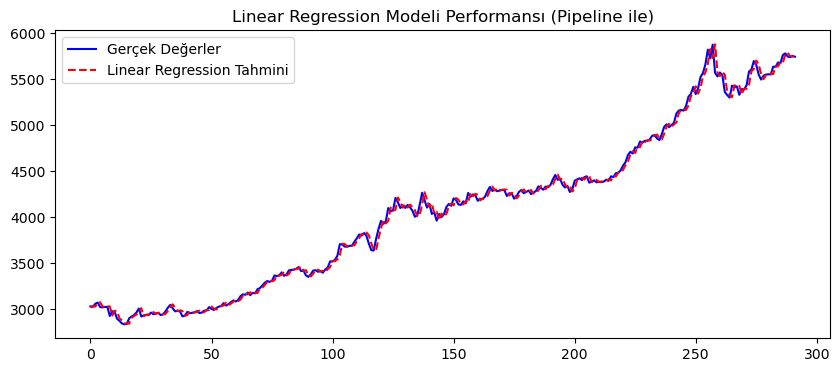

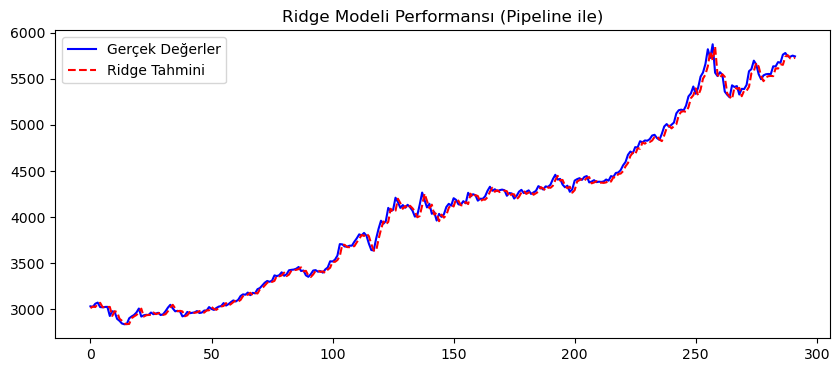

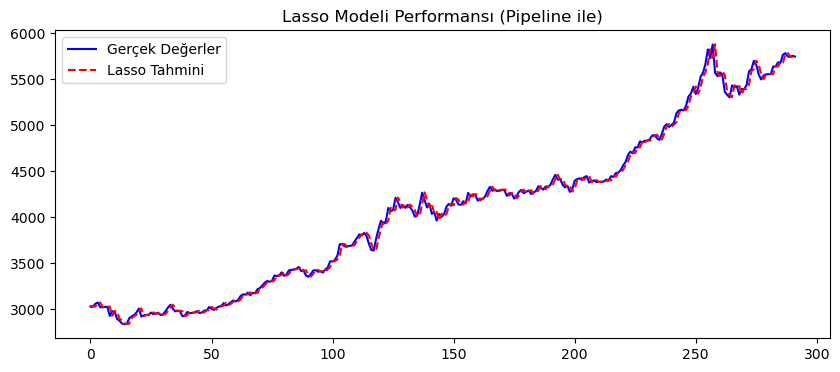

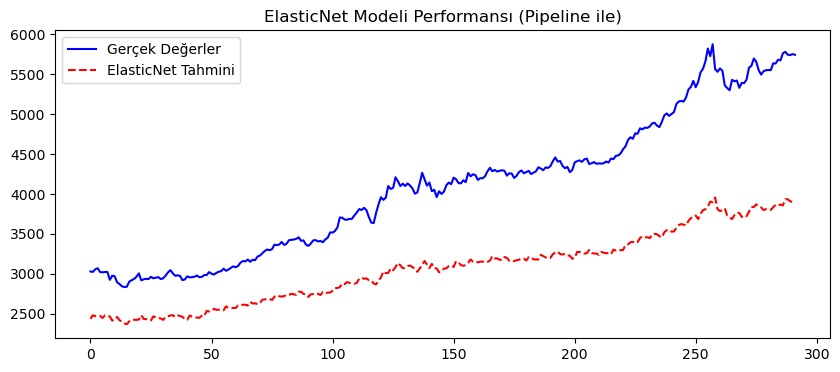

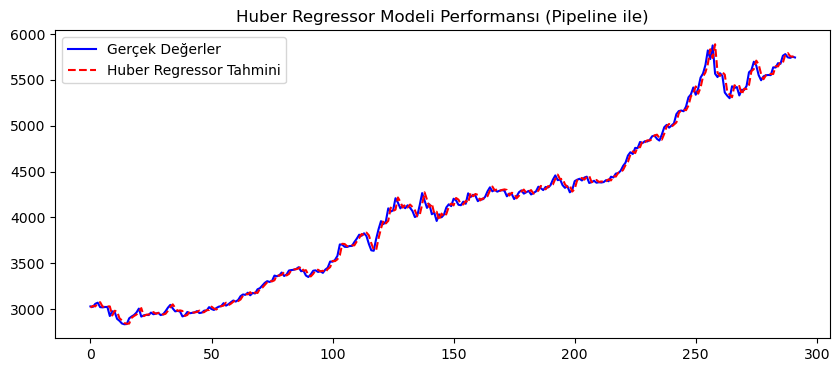

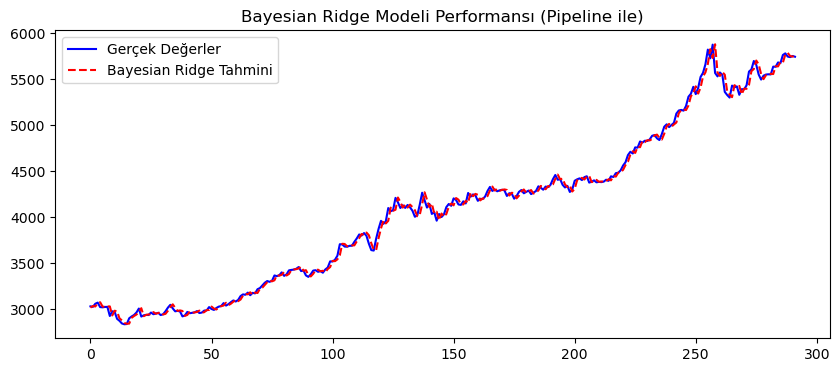

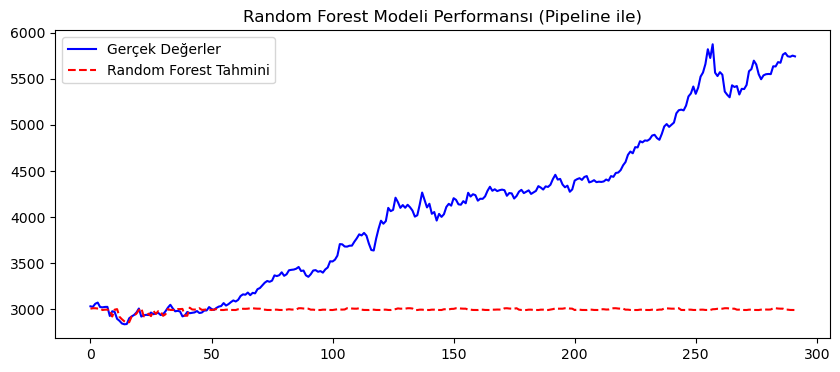

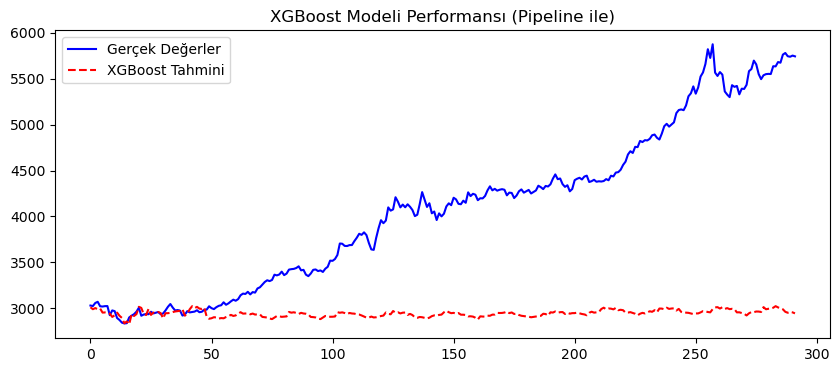

               Model  MAE (Ort. Hata TL)         RMSE  R2 Score (Başarı)
4    Huber Regressor           35.822382    51.403465           0.996523
0  Linear Regression           36.080830    51.581911           0.996499
5     Bayesian Ridge           36.085191    51.585299           0.996499
2              Lasso           36.447807    51.832488           0.996465
1              Ridge           39.666336    55.092665           0.996006
3         ElasticNet         1015.258926  1100.484906          -0.593491
6      Random Forest         1097.922317  1392.937134          -1.552963
7            XGBoost         1143.757633  1426.455095          -1.677304


In [52]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Finans verisi için genelde bu kullanılır
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

results = []
best_score = -np.inf # En iyi skoru takip etmek için (R2'ye göre)
best_pipeline = None # En iyi modeli (pipeline halini) saklamak için
best_model_name = ""

# Döngü
for name, model in models.items():
    
    # --- DEĞİŞİKLİK BURADA BAŞLIYOR ---
    # 1. Pipeline Oluşturma: Önce veriyi Standartlaştır, sonra Modeli çalıştır.
    # Bu sayede 'scaler' sadece X_train istatistiklerini öğrenir, X_test'i buna göre dönüştürür.
    pipe = make_pipeline(StandardScaler(), model)
    
    # 2. Modeli Eğit (Pipeline üzerinden)
    pipe.fit(X_train, y_train)
    
    # 3. Tahmin Yap (Pipeline, X_test'i otomatik scale edip tahmin üretir)
    predictions = pipe.predict(X_test)
    # --- DEĞİŞİKLİK BURADA BİTİYOR ---

    # Metrikleri Hesapla
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "MAE (Ort. Hata TL)": mae,
        "RMSE": rmse,
        "R2 Score (Başarı)": r2
    })
    
    # En iyi modeli hafızada tut (R2 skoruna göre)
    if r2 > best_score:
        best_score = r2
        best_pipeline = pipe # Eğitilmiş pipeline'ı saklıyoruz
        best_model_name = name

    # Grafik Çiz
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.values, label='Gerçek Değerler', color='blue')
    plt.plot(predictions, label=f'{name} Tahmini', color='red', linestyle='--')
    plt.title(f'{name} Modeli Performansı (Pipeline ile)')
    plt.legend()
    plt.show()

# Sonuçları Göster
import pandas as pd
df_results = pd.DataFrame(results).sort_values(by="R2 Score (Başarı)", ascending=False)
print(df_results)

En başarılı model Huber Regressor görünüyor. O zaman onu alıcaz. Bir de Prophet bakalım.

In [183]:
# 1. Veriyi Prophet Formatına Hazırlama
# Prophet katı kurallıdır: Tarih sütunu -> 'ds', Hedef sütun -> 'y' olmalı.
df_prophet = df[['Tarih', 'Kapanis']].copy()
df_prophet.columns = ['ds', 'y']

In [185]:
df_prophet.head()

,ds,y
1,2020-12-08,470.31
2,2020-12-09,462.15
3,2020-12-10,465.70
4,2020-12-11,463.62
5,2020-12-12,463.62


In [187]:
# 2. Train - Test Ayrımı (Yine karıştırmadan, son %20 test)
split_point = int(len(df_prophet) * 0.8)
train = df_prophet.iloc[:split_point]
test = df_prophet.iloc[split_point:]

In [191]:
from prophet import Prophet

In [189]:
# 3. Modeli Kurma ve Eğitme
# daily_seasonality=True: Finans verisi olduğu için günlük değişimler önemli
model_prophet = Prophet(daily_seasonality=True, yearly_seasonality=True) 

model_prophet.fit(train)

17:04:23 - cmdstanpy - INFO - Chain [1] start processing
17:04:24 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
# 4. Tahmin Yapma
# Test seti uzunluğunda bir "gelecek" dataframe'i oluşturmamıza gerek yok,
# direkt test setindeki tarihleri verip tahmin isteyebiliriz.
forecast = model_prophet.predict(test[['ds']])

In [195]:
# 5. Metrikleri Hesaplama
y_true = test['y'].values
y_pred = forecast['yhat'].values # Prophet tahmin sonucuna 'yhat' der

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"--- Prophet Modeli Sonuçları ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

--- Prophet Modeli Sonuçları ---
MAE  : 447.92
RMSE : 575.49
R2   : 0.5642


Modeller arasından yapılan en bşarılı model göründüğü gibi Lasso. Yolumuza demek ki onunla devam edicez.

In [44]:
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Veri Hazırlığı (Senin koduna entegre edilecek kısım) ---
# X_train ve y_train'in hazır olduğunu varsayıyorum.
# Eğer tüm veriyle arama yapacaksan X ve y kullanabilirsin.

# 1. Pipeline Kurulumu
# Huber için de ölçeklendirme (Scaling) şarttır.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('huber', HuberRegressor(max_iter=2000)) # Yakınsama sorunu olmasın diye iterasyonu artırdım
])

# 2. Parametre Izgarası (Grid)
# huber__epsilon: 1.0 (daha çok outlier temizler) ile 2.0 (OLS'ye benzer) arası.
# huber__alpha: Regularization gücü (Ridge gibi çalışır).
param_grid = {
    'huber__epsilon': [1.1, 1.2, 1.35, 1.5, 1.7, 1.9],  # Varsayılan 1.35'tir
    'huber__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
}

# 3. Zaman Serisi Bölücüsü (Veriyi karıştırmadan!)
tscv = TimeSeriesSplit(n_splits=5)

# 4. GridSearch Başlat
print("Huber modeli için en iyi parametreler aranıyor...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error', # Hata karesini minimize et
    n_jobs=-1,
    verbose=1
)

# Aramayı Başlat (Eğitim seti üzerinde)
grid_search.fit(X_train, y_train)

# --- SONUÇLAR ---
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Skor (Negatif MSE): {grid_search.best_score_}")

# En iyi modeli değişkene al
best_huber_model = grid_search.best_estimator_

# Test seti varsa performansına bak
if 'X_test' in locals() and 'y_test' in locals():
    test_score = best_huber_model.score(X_test, y_test)
    print(f"Test Seti R2 Başarısı: {test_score}")

Huber modeli için en iyi parametreler aranıyor...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

En İyi Parametreler: {'huber__alpha': 0.0001, 'huber__epsilon': 1.1}
En İyi Skor (Negatif MSE): -291.07126416306863
Test Seti R2 Başarısı: 0.9965241943770341


In [50]:
np.sqrt(mean_squared_error(y_test, best_huber_model.predict(X_test)))

51.396909710520156

RMSE 51.40 iken 51.39'a düştü. Başarı oranı da yükselti. Huber Modeli seçiyoruz eğitim için. Verimizde en bşarılı gözüken o.